In [1]:
# STEP 1 — IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# STEP 1.1 — FIND DATASET PATH

import os

for dirname, _, filenames in os.walk('/kaggle/input/datasets/bisht31/ibm-train-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
# ============================================
# STEP 1.2 — LOAD DATASET
# ============================================

DATA_PATH = "/kaggle/input/datasets/bisht31/ibm-train-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# ============================================
# STEP 1.3 — DATASET SHAPE
# ============================================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [5]:
# ============================================
# STEP 1.4 — FIRST LOOK
# ============================================

display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# ============================================
# STEP 1.5 — LAST ROWS
# ============================================

display(df.tail())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
# ============================================
# STEP 1.6 — COLUMN NAMES
# ============================================

print("Number of columns:", len(df.columns))
print("\nColumns:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Number of columns: 21

Columns:

1. customerID
2. gender
3. SeniorCitizen
4. Partner
5. Dependents
6. tenure
7. PhoneService
8. MultipleLines
9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn


In [8]:
# ============================================
# STEP 1.7 — DATA TYPES & NON-NULL COUNTS
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# ============================================
# STEP 1.8 — NUMERICAL STATISTICS
# ============================================

display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# ============================================
# STEP 1.9 — CATEGORICAL OVERVIEW
# ============================================

display(df.describe(include='object'))

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [11]:
# STEP 1.10 — BASIC DATASET CHECK

print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())

Dataset shape: (7043, 21)
Duplicate rows: 0
Total missing values: 0


In [12]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing %": (missing.values / len(df)) * 100
})

display(missing_df[missing_df["Missing Values"] > 0])

,Column,Missing Values,Missing %


In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate customer IDs: 0


In [15]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].nunique(), "unique values")
    print(df[col].unique()[:20])


customerID
7043 unique values
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU'
 '9763-GRSKD' '7469-LKBCI' '8091-TTVAX' '0280-XJGEX' '5129-JLPIS'
 '3655-SNQYZ' '8191-XWSZG' '9959-WOFKT' '4190-MFLUW' '4183-MYFRB']

gender
2 unique values
['Female' 'Male']

SeniorCitizen
2 unique values
[0 1]

Partner
2 unique values
['Yes' 'No']

Dependents
2 unique values
['No' 'Yes']

tenure
73 unique values
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30]

PhoneService
2 unique values
['No' 'Yes']

MultipleLines
3 unique values
['No phone service' 'No' 'Yes']

InternetService
3 unique values
['DSL' 'Fiber optic' 'No']

OnlineSecurity
3 unique values
['No' 'Yes' 'No internet service']

OnlineBackup
3 unique values
['Yes' 'No' 'No internet service']

DeviceProtection
3 unique values
['No' 'Yes' 'No internet service']

TechSupport
3 unique values
['No' 'Yes' 'No internet service']

StreamingTV
3 unique values

In [16]:
display(
    pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values
    })
)

,Column,Data Type
0,customerID,object
1,gender,object
2,SeniorCitizen,int64
3,Partner,object
4,Dependents,object
5,tenure,int64
6,PhoneService,object
7,MultipleLines,object
8,InternetService,object
9,OnlineSecurity,object


In [17]:
print("TotalCharges data type:", df["TotalCharges"].dtype)

print("\nFirst 20 values:")
display(df["TotalCharges"].head(20))

TotalCharges data type: object

First 20 values:


0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [18]:
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

invalid_total_charges = total_charges_numeric.isna().sum()

print("Values that cannot be converted to numeric:", invalid_total_charges)

Values that cannot be converted to numeric: 11


In [19]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

display(df[numeric_columns].describe().T)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [20]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [21]:
for col in categorical_columns:
    print(f"\n{'=' * 50}")
    print(col)
    print(df[col].value_counts(dropna=False))


customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
4501-VCPFK    1
6075-SLNIL    1
             ..
1452-KIOVK    1
6713-OKOMC    1
7892-POOKP    1
6388-TABGU    1
9763-GRSKD    1
Name: count, Length: 7043, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429


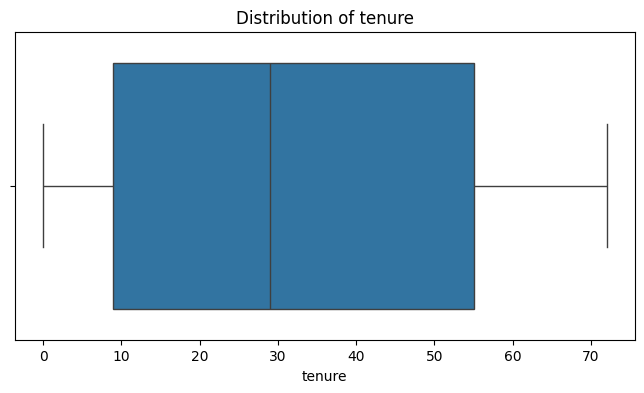

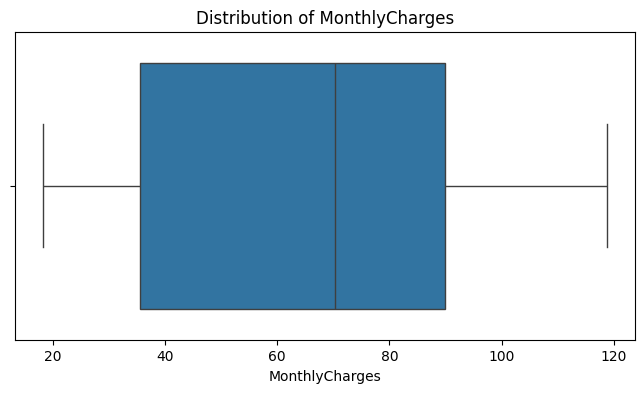

In [22]:
numeric_for_outliers = ["tenure", "MonthlyCharges"]

for col in numeric_for_outliers:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

In [23]:
print("Tenure minimum:", df["tenure"].min())
print("Tenure maximum:", df["tenure"].max())

print("MonthlyCharges minimum:", df["MonthlyCharges"].min())
print("MonthlyCharges maximum:", df["MonthlyCharges"].max())

Tenure minimum: 0
Tenure maximum: 72
MonthlyCharges minimum: 18.25
MonthlyCharges maximum: 118.75


In [24]:
print(df["Churn"].value_counts(dropna=False))

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [25]:
print(df["Churn"].value_counts(normalize=True, dropna=False) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [26]:
churn_counts = df["Churn"].value_counts()

churn_summary = pd.DataFrame({
    "Class": churn_counts.index,
    "Customers": churn_counts.values,
    "Percentage": (churn_counts.values / len(df) * 100).round(2)
})

display(churn_summary)

,Class,Customers,Percentage
0,No,5174,73.46
1,Yes,1869,26.54


In [27]:
non_churn_count = (df["Churn"] == "No").sum()
churn_count = (df["Churn"] == "Yes").sum()

imbalance_ratio = non_churn_count / churn_count

print("Non-churn customers:", non_churn_count)
print("Churn customers:", churn_count)
print("Imbalance ratio:", round(imbalance_ratio, 2))

Non-churn customers: 5174
Churn customers: 1869
Imbalance ratio: 2.77


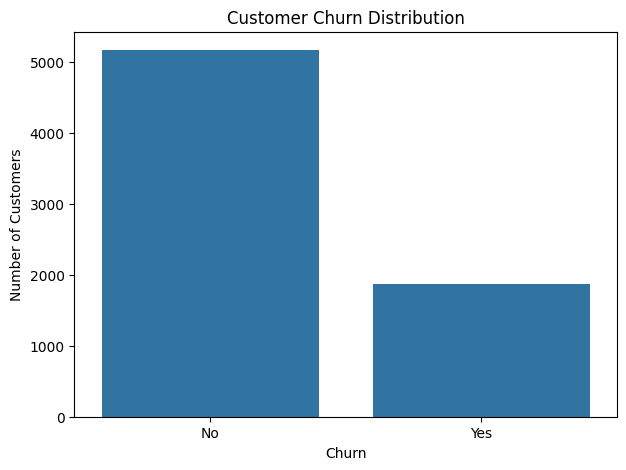

In [28]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

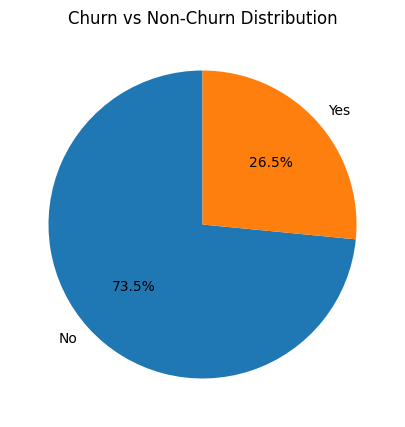

In [29]:
plt.figure(figsize=(7, 5))

churn_percent = df["Churn"].value_counts(normalize=True) * 100

plt.pie(
    churn_percent,
    labels=churn_percent.index,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Churn vs Non-Churn Distribution")

plt.show()

In [30]:
for col in ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]:
    print(f"\n{col}")
    
    temp = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100
    
    display(temp.round(2))


Contract


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83



InternetService


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40



PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11



SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


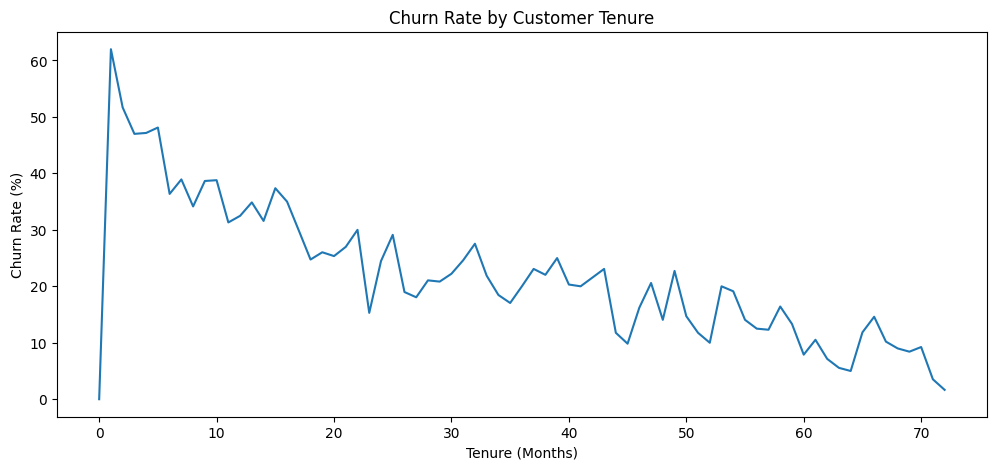

In [31]:
tenure_churn = (
    df.groupby("tenure")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=tenure_churn,
    x="tenure",
    y="ChurnRate"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")

plt.show()

In [32]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

TotalCharges data type: float64
Missing TotalCharges: 11


In [33]:
missing_total = df[df["TotalCharges"].isna()]

display(
    missing_total[
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ]
)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [34]:
print(
    "Tenure values of customers with missing TotalCharges:"
)

print(
    missing_total["tenure"].value_counts()
)

Tenure values of customers with missing TotalCharges:
tenure
0    11
Name: count, dtype: int64


In [35]:
print("Missing TotalCharges with tenure = 0:")

print(
    (missing_total["tenure"] == 0).sum(),
    "out of",
    len(missing_total)
)

Missing TotalCharges with tenure = 0:
11 out of 11


In [36]:
missing_after_totalcharges = df.isnull().sum()

display(
    missing_after_totalcharges[
        missing_after_totalcharges > 0
    ]
)

TotalCharges    11
dtype: int64

In [37]:
model_df = df.drop(columns=["customerID"]).copy()

print("Original shape:", df.shape)
print("Modeling data shape:", model_df.shape)

Original shape: (7043, 21)
Modeling data shape: (7043, 20)


In [38]:
display(model_df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
model_df["TotalCharges"] = model_df["TotalCharges"].fillna(0)

print("Missing TotalCharges:", model_df["TotalCharges"].isna().sum())

Missing TotalCharges: 0


In [40]:
model_df["NewCustomer"] = (model_df["tenure"] <= 6).astype(int)

print(model_df["NewCustomer"].value_counts())

NewCustomer
0    5562
1    1481
Name: count, dtype: int64


In [41]:
model_df["TenureGroup"] = pd.cut(
    model_df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

display(model_df["TenureGroup"].value_counts().sort_index())

TenureGroup
0-6 months      1481
7-12 months      705
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

In [42]:
model_df["IsMonthToMonth"] = (
    model_df["Contract"] == "Month-to-month"
).astype(int)

print(model_df["IsMonthToMonth"].value_counts())

IsMonthToMonth
1    3875
0    3168
Name: count, dtype: int64


In [43]:
model_df["HouseholdSize"] = (
    1
    + (model_df["Partner"] == "Yes").astype(int)
    + (model_df["Dependents"] == "Yes").astype(int)
)

print(model_df["HouseholdSize"].value_counts().sort_index())

HouseholdSize
1    3280
2    2014
3    1749
Name: count, dtype: int64


In [44]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

model_df["ServiceCount"] = 0

for col in service_columns:
    model_df["ServiceCount"] += (
        model_df[col] == "Yes"
    ).astype(int)

print(model_df["ServiceCount"].value_counts().sort_index())

ServiceCount
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64


In [45]:
protection_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

model_df["ProtectionServices"] = 0

for col in protection_columns:
    model_df["ProtectionServices"] += (
        model_df[col] == "Yes"
    ).astype(int)

print(model_df["ProtectionServices"].value_counts().sort_index())

ProtectionServices
0    2793
1    1467
2    1372
3     941
4     470
Name: count, dtype: int64


In [46]:
streaming_columns = [
    "StreamingTV",
    "StreamingMovies"
]

model_df["StreamingCount"] = 0

for col in streaming_columns:
    model_df["StreamingCount"] += (
        model_df[col] == "Yes"
    ).astype(int)

print(model_df["StreamingCount"].value_counts().sort_index())

StreamingCount
0    3544
1    1559
2    1940
Name: count, dtype: int64


In [47]:
model_df["AvgMonthlySpend"] = np.where(
    model_df["tenure"] > 0,
    model_df["TotalCharges"] / model_df["tenure"],
    model_df["MonthlyCharges"]
)

print(model_df["AvgMonthlySpend"].describe())

count    7043.000000
mean       64.762906
std        30.189796
min        13.775000
25%        35.935156
50%        70.337500
75%        90.174158
max       121.400000
Name: AvgMonthlySpend, dtype: float64


In [48]:
new_features = [
    "NewCustomer",
    "TenureGroup",
    "IsMonthToMonth",
    "HouseholdSize",
    "ServiceCount",
    "ProtectionServices",
    "StreamingCount",
    "AvgMonthlySpend"
]

display(model_df[new_features].head(10))

,NewCustomer,TenureGroup,IsMonthToMonth,HouseholdSize,ServiceCount,ProtectionServices,StreamingCount,AvgMonthlySpend
0,1,0-6 months,1,2,1,1,0,29.850000
1,0,25-48 months,0,1,3,2,0,55.573529
2,1,0-6 months,1,1,3,2,0,54.075000
3,0,25-48 months,0,1,3,3,0,40.905556
4,1,0-6 months,1,1,1,0,0,75.825000
5,0,7-12 months,1,1,5,1,2,102.562500
6,0,13-24 months,1,2,4,1,1,88.609091
7,0,7-12 months,1,1,1,1,0,30.190000
8,0,25-48 months,1,2,6,2,2,108.787500
9,0,49-72 months,0,2,3,2,0,56.257258


In [49]:
print("Total columns:", len(model_df.columns))

for i, col in enumerate(model_df.columns, start=1):
    print(f"{i}. {col}")

Total columns: 28
1. gender
2. SeniorCitizen
3. Partner
4. Dependents
5. tenure
6. PhoneService
7. MultipleLines
8. InternetService
9. OnlineSecurity
10. OnlineBackup
11. DeviceProtection
12. TechSupport
13. StreamingTV
14. StreamingMovies
15. Contract
16. PaperlessBilling
17. PaymentMethod
18. MonthlyCharges
19. TotalCharges
20. Churn
21. NewCustomer
22. TenureGroup
23. IsMonthToMonth
24. HouseholdSize
25. ServiceCount
26. ProtectionServices
27. StreamingCount
28. AvgMonthlySpend


In [50]:
model_df["Churn"] = model_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(model_df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [51]:
X = model_df.drop(columns=["Churn"]).copy()
y = model_df["Churn"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 27)
y shape: (7043,)


In [52]:
print("Target variable:")
print(y.value_counts())

print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Target variable:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target percentages:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [53]:
print("Numerical features:")

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print(numeric_features)

print("\nCategorical features:")

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NewCustomer', 'IsMonthToMonth', 'HouseholdSize', 'ServiceCount', 'ProtectionServices', 'StreamingCount', 'AvgMonthlySpend']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [54]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 5634
Test samples: 1409


In [56]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest class distribution:")
print(y_test.value_counts())

print("\nTest percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Training percentages:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Test class distribution:
Churn
0    1035
1     374
Name: count, dtype: int64

Test percentages:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [57]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 27)
X_test shape: (1409, 27)
y_train shape: (5634,)
y_test shape: (1409,)


In [58]:
print("Training churn rate:", round(y_train.mean() * 100, 2), "%")
print("Test churn rate:", round(y_test.mean() * 100, 2), "%")

Training churn rate: 26.54 %
Test churn rate: 26.54 %


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [60]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NewCustomer', 'IsMonthToMonth', 'HouseholdSize', 'ServiceCount', 'ProtectionServices', 'StreamingCount', 'AvgMonthlySpend']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [61]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [62]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [63]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [64]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (5634, 57)
Processed test shape: (1409, 57)


In [65]:
preprocessor.fit_transform(X_train)

array([[-0.44177295,  0.10237124, -0.52197565, ...,  1.        ,
         0.        ,  0.        ],
       [-0.44177295, -0.71174346,  0.33747781, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295, -0.79315493, -0.80901319, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 2.2636062 , -0.30468611,  1.25666162, ...,  1.        ,
         0.        ,  0.        ],
       [-0.44177295, -0.34539184, -1.47766135, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295, -1.07809507, -1.46936546, ...,  0.        ,
         0.        ,  0.        ]])

In [66]:
preprocessor.transform(X_test)

array([[-0.44177295,  1.60848343,  1.62997635, ...,  0.        ,
         1.        ,  0.        ],
       [ 2.2636062 , -0.9966836 ,  1.16872526, ...,  0.        ,
         0.        ,  1.        ],
       [-0.44177295,  0.34660565,  0.44532428, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.44177295, -1.11880081, -1.46936546, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295,  0.95719167, -1.50088982, ...,  0.        ,
         1.        ,  0.        ],
       [-0.44177295,  1.60848343,  0.18317439, ...,  0.        ,
         1.        ,  0.        ]])

In [67]:
print("Training processed data type:", type(X_train_processed))
print("Test processed data type:", type(X_test_processed))

print("Any NaN in training:", np.isnan(X_train_processed).sum())
print("Any NaN in test:", np.isnan(X_test_processed).sum())

Training processed data type: <class 'numpy.ndarray'>
Test processed data type: <class 'numpy.ndarray'>
Any NaN in training: 0
Any NaN in test: 0


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train)

y_pred_baseline = baseline_model.predict(X_test_processed)
y_prob_baseline = baseline_model.predict_proba(X_test_processed)[:, 1]

print("Baseline Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, y_pred_baseline), 4))
print("Precision:", round(precision_score(y_test, y_pred_baseline), 4))
print("Recall:", round(recall_score(y_test, y_pred_baseline), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_baseline), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_baseline), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_baseline), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

Baseline Logistic Regression
Accuracy: 0.7991
Precision: 0.6564
Recall: 0.5107
F1 Score: 0.5744
ROC-AUC: 0.8451
PR-AUC: 0.6504

Confusion Matrix:
[[935 100]
 [183 191]]


In [69]:
weighted_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

weighted_lr.fit(X_train_processed, y_train)

y_pred_weighted = weighted_lr.predict(X_test_processed)
y_prob_weighted = weighted_lr.predict_proba(X_test_processed)[:, 1]

print("Class-Weighted Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, y_pred_weighted), 4))
print("Precision:", round(precision_score(y_test, y_pred_weighted), 4))
print("Recall:", round(recall_score(y_test, y_pred_weighted), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_weighted), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_weighted), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_weighted), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_weighted))

Class-Weighted Logistic Regression
Accuracy: 0.7395
Precision: 0.5059
Recall: 0.8021
F1 Score: 0.6205
ROC-AUC: 0.8448
PR-AUC: 0.6502

Confusion Matrix:
[[742 293]
 [ 74 300]]


In [70]:
from imblearn.over_sampling import SMOTE

In [71]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Original training shape:", X_train_processed.shape)
print("SMOTE training shape:", X_train_smote.shape)

print("\nOriginal class distribution:")
print(y_train.value_counts())

print("\nSMOTE class distribution:")
print(y_train_smote.value_counts())

Original training shape: (5634, 57)
SMOTE training shape: (8278, 57)

Original class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

SMOTE class distribution:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [72]:
smote_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_lr.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_lr.predict(X_test_processed)
y_prob_smote = smote_lr.predict_proba(X_test_processed)[:, 1]

print("SMOTE Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, y_pred_smote), 4))
print("Precision:", round(precision_score(y_test, y_pred_smote), 4))
print("Recall:", round(recall_score(y_test, y_pred_smote), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_smote), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_smote), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_smote), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

SMOTE Logistic Regression
Accuracy: 0.7445
Precision: 0.5119
Recall: 0.8021
F1 Score: 0.625
ROC-AUC: 0.8414
PR-AUC: 0.6453

Confusion Matrix:
[[749 286]
 [ 74 300]]


In [73]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [74]:
underbagging_model = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

underbagging_model.fit(X_train_processed, y_train)

y_pred_under = underbagging_model.predict(X_test_processed)
y_prob_under = underbagging_model.predict_proba(X_test_processed)[:, 1]

print("Underbagging Model")
print("Accuracy:", round(accuracy_score(y_test, y_pred_under), 4))
print("Precision:", round(precision_score(y_test, y_pred_under), 4))
print("Recall:", round(recall_score(y_test, y_pred_under), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_under), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_under), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_under), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_under))

Underbagging Model
Accuracy: 0.7594
Precision: 0.5314
Recall: 0.7914
F1 Score: 0.6359
ROC-AUC: 0.8443
PR-AUC: 0.6508

Confusion Matrix:
[[774 261]
 [ 78 296]]


In [75]:
lr_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + Class Weight",
        "Logistic Regression + SMOTE",
        "Underbagging"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_weighted),
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_under)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_weighted),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_under)
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_weighted),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_under)
    ],
    "F1": [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_weighted),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_under)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_baseline),
        roc_auc_score(y_test, y_prob_weighted),
        roc_auc_score(y_test, y_prob_smote),
        roc_auc_score(y_test, y_prob_under)
    ],
    "PR_AUC": [
        average_precision_score(y_test, y_prob_baseline),
        average_precision_score(y_test, y_prob_weighted),
        average_precision_score(y_test, y_prob_smote),
        average_precision_score(y_test, y_prob_under)
    ]
})

print(lr_results.round(4))

                                Model  Accuracy  Precision  Recall      F1  \
0                 Logistic Regression    0.7991     0.6564  0.5107  0.5744   
1  Logistic Regression + Class Weight    0.7395     0.5059  0.8021  0.6205   
2         Logistic Regression + SMOTE    0.7445     0.5119  0.8021  0.6250   
3                        Underbagging    0.7594     0.5314  0.7914  0.6359   

   ROC_AUC  PR_AUC  
0   0.8451  0.6504  
1   0.8448  0.6502  
2   0.8414  0.6453  
3   0.8443  0.6508  


In [76]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.7821
Precision: 0.6159
Recall: 0.4759
F1 Score: 0.537
ROC-AUC: 0.8237
PR-AUC: 0.6181

Confusion Matrix:
[[924 111]
 [196 178]]


In [77]:
import lightgbm as lgb

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


In [78]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(X_train_processed, y_train)

y_pred_lgb = lgb_model.predict(X_test_processed)
y_prob_lgb = lgb_model.predict_proba(X_test_processed)[:, 1]

print("LightGBM")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_lgb), 4))
print("Recall:", round(recall_score(y_test, y_pred_lgb), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_lgb), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lgb), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_lgb), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb))

LightGBM
Accuracy: 0.7622
Precision: 0.5397
Recall: 0.7086
F1 Score: 0.6127
ROC-AUC: 0.8362
PR-AUC: 0.6439

Confusion Matrix:
[[809 226]
 [109 265]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [79]:
!pip install -q interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 62.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.1/800.1 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 10.3 MB/s eta 0:00:00


In [80]:
from interpret.glassbox import ExplainableBoostingClassifier

In [81]:
ebm_model = ExplainableBoostingClassifier(
    interactions=10,
    max_bins=256,
    max_rounds=500,
    learning_rate=0.03,
    validation_size=0.15,
    random_state=42
)

ebm_model.fit(X_train_processed, y_train)

y_pred_ebm = ebm_model.predict(X_test_processed)
y_prob_ebm = ebm_model.predict_proba(X_test_processed)[:, 1]

print("EBM")
print("Accuracy:", round(accuracy_score(y_test, y_pred_ebm), 4))
print("Precision:", round(precision_score(y_test, y_pred_ebm), 4))
print("Recall:", round(recall_score(y_test, y_pred_ebm), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_ebm), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_ebm), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob_ebm), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ebm))

EBM
Accuracy: 0.8027
Precision: 0.66
Recall: 0.5294
F1 Score: 0.5875
ROC-AUC: 0.8457
PR-AUC: 0.6609

Confusion Matrix:
[[933 102]
 [176 198]]


In [82]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

In [83]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

print("Total CV runs:", cv.get_n_splits(X_train, y_train))

Total CV runs: 15


In [84]:
from sklearn.pipeline import Pipeline

lr_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [85]:
lr_cv_results = cross_validate(
    lr_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1,
    return_train_score=False
)

print("Logistic Regression - 5-Fold × 3 CV")

print(
    "ROC-AUC:",
    round(lr_cv_results["test_roc_auc"].mean(), 4),
    "+/-",
    round(lr_cv_results["test_roc_auc"].std(), 4)
)

print(
    "PR-AUC:",
    round(lr_cv_results["test_pr_auc"].mean(), 4),
    "+/-",
    round(lr_cv_results["test_pr_auc"].std(), 4)
)

Logistic Regression - 5-Fold × 3 CV
ROC-AUC: 0.8478 +/- 0.0119
PR-AUC: 0.663 +/- 0.0193


In [86]:
from sklearn.base import clone

ebm_cv_scores = {
    "roc_auc": [],
    "pr_auc": []
}

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    fold_preprocessor = clone(preprocessor)

    X_fold_train_processed = fold_preprocessor.fit_transform(
        X_fold_train
    )

    X_fold_val_processed = fold_preprocessor.transform(
        X_fold_val
    )

    fold_ebm = ExplainableBoostingClassifier(
        interactions=10,
        max_bins=256,
        max_rounds=500,
        learning_rate=0.03,
        validation_size=0.15,
        random_state=42
    )

    fold_ebm.fit(
        X_fold_train_processed,
        y_fold_train
    )

    fold_prob = fold_ebm.predict_proba(
        X_fold_val_processed
    )[:, 1]

    ebm_cv_scores["roc_auc"].append(
        roc_auc_score(y_fold_val, fold_prob)
    )

    ebm_cv_scores["pr_auc"].append(
        average_precision_score(y_fold_val, fold_prob)
    )

print("EBM - 5-Fold × 3 CV")

print(
    "ROC-AUC:",
    round(np.mean(ebm_cv_scores["roc_auc"]), 4),
    "+/-",
    round(np.std(ebm_cv_scores["roc_auc"]), 4)
)

print(
    "PR-AUC:",
    round(np.mean(ebm_cv_scores["pr_auc"]), 4),
    "+/-",
    round(np.std(ebm_cv_scores["pr_auc"]), 4)
)

EBM - 5-Fold × 3 CV
ROC-AUC: 0.8498 +/- 0.0118
PR-AUC: 0.6682 +/- 0.0192


In [87]:
rf_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_cv_results = cross_validate(
    rf_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1,
    return_train_score=False
)

print("Random Forest - 5-Fold × 3 CV")

print(
    "ROC-AUC:",
    round(rf_cv_results["test_roc_auc"].mean(), 4),
    "+/-",
    round(rf_cv_results["test_roc_auc"].std(), 4)
)

print(
    "PR-AUC:",
    round(rf_cv_results["test_pr_auc"].mean(), 4),
    "+/-",
    round(rf_cv_results["test_pr_auc"].std(), 4)
)

Random Forest - 5-Fold × 3 CV
ROC-AUC: 0.8295 +/- 0.0132
PR-AUC: 0.625 +/- 0.0289


In [88]:
lgb_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ))
    ]
)

lgb_cv_results = cross_validate(
    lgb_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1,
    return_train_score=False
)

print("LightGBM - 5-Fold × 3 CV")

print(
    "ROC-AUC:",
    round(lgb_cv_results["test_roc_auc"].mean(), 4),
    "+/-",
    round(lgb_cv_results["test_roc_auc"].std(), 4)
)

print(
    "PR-AUC:",
    round(lgb_cv_results["test_pr_auc"].mean(), 4),
    "+/-",
    round(lgb_cv_results["test_pr_auc"].std(), 4)
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warning

LightGBM - 5-Fold × 3 CV
ROC-AUC: 0.8348 +/- 0.0119
PR-AUC: 0.6446 +/- 0.0236


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [89]:
lgb_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
            verbosity=-1
        ))
    ]
)

lgb_cv_results = cross_validate(
    lgb_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=1,
    return_train_score=False
)

print("LightGBM - 5-Fold × 3 CV")

print(
    "ROC-AUC:",
    round(lgb_cv_results["test_roc_auc"].mean(), 4),
    "+/-",
    round(lgb_cv_results["test_roc_auc"].std(), 4)
)

print(
    "PR-AUC:",
    round(lgb_cv_results["test_pr_auc"].mean(), 4),
    "+/-",
    round(lgb_cv_results["test_pr_auc"].std(), 4)
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM - 5-Fold × 3 CV
ROC-AUC: 0.8348 +/- 0.0119
PR-AUC: 0.6446 +/- 0.0236


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [90]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

lr_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)

lr_param_distributions = {
    "model__C": loguniform(0.001, 100),
    "model__class_weight": [None, "balanced"],
    "model__solver": ["lbfgs", "liblinear"]
}

lr_random_search = RandomizedSearchCV(
    estimator=lr_tuning_pipeline,
    param_distributions=lr_param_distributions,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=False
)

lr_random_search.fit(X_train, y_train)

print("Best parameters:")
print(lr_random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(lr_random_search.best_score_, 4))


Best parameters:
{'model__C': np.float64(0.028888383623653185), 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}

Best CV ROC-AUC:
0.8482


In [91]:
ebm_param_combinations = [
    {
        "learning_rate": 0.01,
        "max_rounds": 300,
        "max_bins": 128,
        "interactions": 5
    },
    {
        "learning_rate": 0.03,
        "max_rounds": 500,
        "max_bins": 256,
        "interactions": 10
    },
    {
        "learning_rate": 0.05,
        "max_rounds": 500,
        "max_bins": 256,
        "interactions": 10
    },
    {
        "learning_rate": 0.03,
        "max_rounds": 700,
        "max_bins": 256,
        "interactions": 15
    },
    {
        "learning_rate": 0.05,
        "max_rounds": 700,
        "max_bins": 128,
        "interactions": 15
    }
]

ebm_tuning_results = []

for i, params in enumerate(ebm_param_combinations, start=1):

    print(f"Testing configuration {i}/{len(ebm_param_combinations)}")

    fold_roc_auc = []
    fold_pr_auc = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        fold_preprocessor = clone(preprocessor)

        X_fold_train_processed = fold_preprocessor.fit_transform(
            X_fold_train
        )

        X_fold_val_processed = fold_preprocessor.transform(
            X_fold_val
        )

        model = ExplainableBoostingClassifier(
            learning_rate=params["learning_rate"],
            max_rounds=params["max_rounds"],
            max_bins=params["max_bins"],
            interactions=params["interactions"],
            validation_size=0.15,
            random_state=42
        )

        model.fit(
            X_fold_train_processed,
            y_fold_train
        )

        y_prob = model.predict_proba(
            X_fold_val_processed
        )[:, 1]

        fold_roc_auc.append(
            roc_auc_score(y_fold_val, y_prob)
        )

        fold_pr_auc.append(
            average_precision_score(y_fold_val, y_prob)
        )

    result = {
        "Configuration": i,
        "Learning_Rate": params["learning_rate"],
        "Max_Rounds": params["max_rounds"],
        "Max_Bins": params["max_bins"],
        "Interactions": params["interactions"],
        "ROC_AUC_Mean": np.mean(fold_roc_auc),
        "ROC_AUC_SD": np.std(fold_roc_auc),
        "PR_AUC_Mean": np.mean(fold_pr_auc),
        "PR_AUC_SD": np.std(fold_pr_auc)
    }

    ebm_tuning_results.append(result)

ebm_tuning_df = pd.DataFrame(ebm_tuning_results)

print("\nEBM Tuning Results:")
print(
    ebm_tuning_df.sort_values(
        "ROC_AUC_Mean",
        ascending=False
    ).round(4)
)

Testing configuration 1/5
Testing configuration 2/5
Testing configuration 3/5
Testing configuration 4/5
Testing configuration 5/5

EBM Tuning Results:
   Configuration  Learning_Rate  Max_Rounds  Max_Bins  Interactions  \
0              1           0.01         300       128             5   
2              3           0.05         500       256            10   
1              2           0.03         500       256            10   
4              5           0.05         700       128            15   
3              4           0.03         700       256            15   

   ROC_AUC_Mean  ROC_AUC_SD  PR_AUC_Mean  PR_AUC_SD  
0        0.8503      0.0117       0.6689     0.0196  
2        0.8499      0.0119       0.6684     0.0190  
1        0.8498      0.0118       0.6682     0.0192  
4        0.8497      0.0120       0.6670     0.0205  
3        0.8497      0.0120       0.6672     0.0201  


In [92]:
!pip install -q xgboost

from xgboost import XGBClassifier

In [93]:
xgb_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            min_child_weight=2,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=1
        ))
    ]
)

xgb_cv_results = cross_validate(
    xgb_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=1,
    return_train_score=False
)

print("XGBoost - 5-Fold × 3 CV")

print(
    "ROC-AUC:",
    round(xgb_cv_results["test_roc_auc"].mean(), 4),
    "+/-",
    round(xgb_cv_results["test_roc_auc"].std(), 4)
)

print(
    "PR-AUC:",
    round(xgb_cv_results["test_pr_auc"].mean(), 4),
    "+/-",
    round(xgb_cv_results["test_pr_auc"].std(), 4)
)

XGBoost - 5-Fold × 3 CV
ROC-AUC: 0.8465 +/- 0.0123
PR-AUC: 0.6646 +/- 0.0232


In [94]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "LightGBM",
        "XGBoost",
        "EBM"
    ],
    "ROC_AUC_Mean": [
        0.8478,
        0.8295,
        0.8348,
        0.8465,
        0.8503
    ],
    "ROC_AUC_SD": [
        0.0119,
        0.0132,
        0.0119,
        0.0123,
        0.0117
    ],
    "PR_AUC_Mean": [
        0.6630,
        0.6250,
        0.6446,
        0.6646,
        0.6689
    ],
    "PR_AUC_SD": [
        0.0193,
        0.0289,
        0.0236,
        0.0232,
        0.0196
    ]
})

print(
    model_comparison
    .sort_values("ROC_AUC_Mean", ascending=False)
    .round(4)
)

                 Model  ROC_AUC_Mean  ROC_AUC_SD  PR_AUC_Mean  PR_AUC_SD
4                  EBM        0.8503      0.0117       0.6689     0.0196
0  Logistic Regression        0.8478      0.0119       0.6630     0.0193
3              XGBoost        0.8465      0.0123       0.6646     0.0232
2             LightGBM        0.8348      0.0119       0.6446     0.0236
1        Random Forest        0.8295      0.0132       0.6250     0.0289


In [95]:
ebm_roc = 0.8503
ebm_pr = 0.6689

comparison = model_comparison.copy()

comparison["ROC_AUC_Difference_vs_EBM"] = (
    comparison["ROC_AUC_Mean"] - ebm_roc
)

comparison["PR_AUC_Difference_vs_EBM"] = (
    comparison["PR_AUC_Mean"] - ebm_pr
)

print(
    comparison
    .sort_values("ROC_AUC_Mean", ascending=False)
    .round(4)
)

                 Model  ROC_AUC_Mean  ROC_AUC_SD  PR_AUC_Mean  PR_AUC_SD  \
4                  EBM        0.8503      0.0117       0.6689     0.0196   
0  Logistic Regression        0.8478      0.0119       0.6630     0.0193   
3              XGBoost        0.8465      0.0123       0.6646     0.0232   
2             LightGBM        0.8348      0.0119       0.6446     0.0236   
1        Random Forest        0.8295      0.0132       0.6250     0.0289   

   ROC_AUC_Difference_vs_EBM  PR_AUC_Difference_vs_EBM  
4                     0.0000                    0.0000  
0                    -0.0025                   -0.0059  
3                    -0.0038                   -0.0043  
2                    -0.0155                   -0.0243  
1                    -0.0208                   -0.0439  


In [96]:
from interpret.glassbox import ExplainableBoostingClassifier

final_ebm_candidate = ExplainableBoostingClassifier(
    interactions=5,
    max_bins=128,
    max_rounds=300,
    learning_rate=0.01,
    validation_size=0.15,
    random_state=42
)

final_ebm_candidate.fit(X_train_processed, y_train)

print("Tuned EBM trained successfully.")

Tuned EBM trained successfully.


In [97]:
ebm_test_prob = final_ebm_candidate.predict_proba(X_test_processed)[:, 1]

print("First 10 predicted probabilities:")
print(ebm_test_prob[:10])

First 10 predicted probabilities:
[0.02548953 0.73722946 0.05985184 0.29901904 0.01715027 0.5800623
 0.42442107 0.09296302 0.00864216 0.39777804]


In [98]:
from sklearn.metrics import brier_score_loss

ebm_brier = brier_score_loss(y_test, ebm_test_prob)

print(f"EBM Brier Score: {ebm_brier:.4f}")

EBM Brier Score: 0.1358


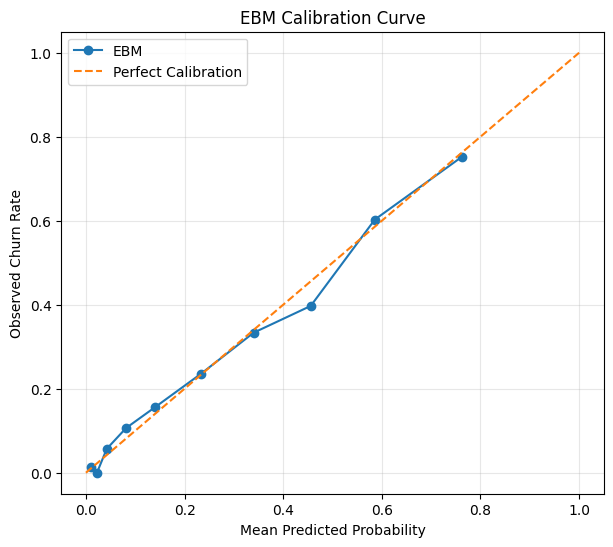

In [99]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    ebm_test_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="EBM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("EBM Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [100]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    average_precision_score
)

calibration_ebm = clone(final_ebm_candidate)

calibrated_ebm = CalibratedClassifierCV(
    estimator=calibration_ebm,
    method="sigmoid",
    cv=5
)

calibrated_ebm.fit(X_train_processed, y_train)

calibrated_test_prob = calibrated_ebm.predict_proba(
    X_test_processed
)[:, 1]

calibrated_brier = brier_score_loss(
    y_test,
    calibrated_test_prob
)

calibrated_roc = roc_auc_score(
    y_test,
    calibrated_test_prob
)

calibrated_pr = average_precision_score(
    y_test,
    calibrated_test_prob
)

print(f"Original EBM Brier Score: {ebm_brier:.4f}")
print(f"Calibrated EBM Brier Score: {calibrated_brier:.4f}")
print(f"Original EBM ROC-AUC: {roc_auc_score(y_test, ebm_test_prob):.4f}")
print(f"Calibrated EBM ROC-AUC: {calibrated_roc:.4f}")
print(f"Original EBM PR-AUC: {average_precision_score(y_test, ebm_test_prob):.4f}")
print(f"Calibrated EBM PR-AUC: {calibrated_pr:.4f}")

Original EBM Brier Score: 0.1358
Calibrated EBM Brier Score: 0.1355
Original EBM ROC-AUC: 0.8448
Calibrated EBM ROC-AUC: 0.8455
Original EBM PR-AUC: 0.6596
Calibrated EBM PR-AUC: 0.6611


In [101]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

final_threshold = 0.50

calibrated_test_pred = (
    calibrated_test_prob >= final_threshold
).astype(int)

final_accuracy = accuracy_score(
    y_test,
    calibrated_test_pred
)

final_precision = precision_score(
    y_test,
    calibrated_test_pred
)

final_recall = recall_score(
    y_test,
    calibrated_test_pred
)

final_f1 = f1_score(
    y_test,
    calibrated_test_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    calibrated_test_prob
)

final_pr_auc = average_precision_score(
    y_test,
    calibrated_test_prob
)

final_brier = brier_score_loss(
    y_test,
    calibrated_test_prob
)

final_cm = confusion_matrix(
    y_test,
    calibrated_test_pred
)

print("Final EBM Evaluation")
print("-" * 30)
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")
print(f"PR-AUC    : {final_pr_auc:.4f}")
print(f"Brier     : {final_brier:.4f}")

print("\nConfusion Matrix:")
print(final_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        calibrated_test_pred,
        target_names=["No Churn", "Churn"]
    )
)

Final EBM Evaluation
------------------------------
Accuracy  : 0.8070
Precision : 0.6723
Recall    : 0.5321
F1 Score  : 0.5940
ROC-AUC   : 0.8455
PR-AUC    : 0.6611
Brier     : 0.1355

Confusion Matrix:
[[938  97]
 [175 199]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [102]:
final_model_summary = pd.DataFrame({
    "Model": [
        "EBM",
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "Random Forest"
    ],
    "CV_ROC_AUC": [
        0.8503,
        0.8478,
        0.8465,
        0.8348,
        0.8295
    ],
    "CV_PR_AUC": [
        0.6689,
        0.6630,
        0.6646,
        0.6446,
        0.6250
    ],
    "Test_ROC_AUC": [
        0.8455,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ],
    "Test_PR_AUC": [
        0.6611,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ],
    "Brier_Score": [
        0.1355,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ],
    "Explainable": [
        "Yes",
        "Yes",
        "Limited",
        "Limited",
        "Limited"
    ]
})

print(final_model_summary.round(4))

                 Model  CV_ROC_AUC  CV_PR_AUC  Test_ROC_AUC  Test_PR_AUC  \
0                  EBM      0.8503     0.6689        0.8455       0.6611   
1  Logistic Regression      0.8478     0.6630           NaN          NaN   
2              XGBoost      0.8465     0.6646           NaN          NaN   
3             LightGBM      0.8348     0.6446           NaN          NaN   
4        Random Forest      0.8295     0.6250           NaN          NaN   

   Brier_Score Explainable  
0       0.1355         Yes  
1          NaN         Yes  
2          NaN     Limited  
3          NaN     Limited  
4          NaN     Limited  


In [103]:
global_explanation = final_ebm_candidate.explain_global()

print(global_explanation)

In [104]:
importance = global_explanation.data()["scores"]
names = global_explanation.data()["names"]

feature_importance = pd.DataFrame({
    "Feature": names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(15).round(4))

         Feature  Importance
45  feature_0045      0.2108
43  feature_0043      0.1855
5   feature_0005      0.1854
1   feature_0001      0.1730
3   feature_0003      0.1653
23  feature_0023      0.1585
22  feature_0022      0.1209
55  feature_0055      0.1201
25  feature_0025      0.1167
52  feature_0052      0.1140
4   feature_0004      0.1139
50  feature_0050      0.1090
34  feature_0034      0.1029
10  feature_0010      0.0994
2   feature_0002      0.0969


In [105]:
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(processed_feature_names))

for i, name in enumerate(processed_feature_names):
    print(i, "->", name)

Number of processed features: 57
0 -> num__SeniorCitizen
1 -> num__tenure
2 -> num__MonthlyCharges
3 -> num__TotalCharges
4 -> num__NewCustomer
5 -> num__IsMonthToMonth
6 -> num__HouseholdSize
7 -> num__ServiceCount
8 -> num__ProtectionServices
9 -> num__StreamingCount
10 -> num__AvgMonthlySpend
11 -> cat__gender_Female
12 -> cat__gender_Male
13 -> cat__Partner_No
14 -> cat__Partner_Yes
15 -> cat__Dependents_No
16 -> cat__Dependents_Yes
17 -> cat__PhoneService_No
18 -> cat__PhoneService_Yes
19 -> cat__MultipleLines_No
20 -> cat__MultipleLines_No phone service
21 -> cat__MultipleLines_Yes
22 -> cat__InternetService_DSL
23 -> cat__InternetService_Fiber optic
24 -> cat__InternetService_No
25 -> cat__OnlineSecurity_No
26 -> cat__OnlineSecurity_No internet service
27 -> cat__OnlineSecurity_Yes
28 -> cat__OnlineBackup_No
29 -> cat__OnlineBackup_No internet service
30 -> cat__OnlineBackup_Yes
31 -> cat__DeviceProtection_No
32 -> cat__DeviceProtection_No internet service
33 -> cat__DeviceProte

In [106]:
importance = global_explanation.data()["scores"]

feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(feature_importance.head(20).round(4))

ValueError: All arrays must be of the same length

In [ ]:
print("Number of EBM feature scores:",
      len(global_explanation.data()["scores"]))

print("Number of EBM feature names:",
      len(global_explanation.data()["names"]))

print("\nEBM feature names:")
for i, name in enumerate(global_explanation.data()["names"]):
    print(i, "->", name)

In [ ]:
print("Number of features used by EBM:",
      len(final_ebm_candidate.feature_names))

print("\nEBM model feature names:")
for i, name in enumerate(final_ebm_candidate.feature_names):
    print(i, "->", name)

In [ ]:
ebm_data = global_explanation.data()

print("Number of EBM scores:", len(ebm_data["scores"]))
print("Number of EBM names:", len(ebm_data["names"]))

print("\nEBM names:")
for i, name in enumerate(ebm_data["names"]):
    print(i, "->", name)

In [ ]:

print("Processed feature count:",
      X_train_processed.shape[1])

print("\nPreprocessor feature names:")
for i, name in enumerate(preprocessor.get_feature_names_out()):
    print(i, "->", name)

In [ ]:
ebm_scores = global_explanation.data()["scores"]

processed_feature_names = preprocessor.get_feature_names_out()

main_feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": ebm_scores[:len(processed_feature_names)]
})

main_feature_importance = main_feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(main_feature_importance.head(20).round(4))

In [ ]:
interaction_names = global_explanation.data()["names"][57:]
interaction_scores = ebm_scores[57:]

interaction_importance = pd.DataFrame({
    "Interaction": interaction_names,
    "Importance": interaction_scores
})

interaction_importance = interaction_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(interaction_importance.round(4))

In [ ]:
feature_data = global_explanation.data()
print(feature_data.keys())

print(type(global_explanation))
print(type(global_explanation.data()))

print(global_explanation.data()["names"][:10])

In [ ]:
print("Number of additive terms:", len(final_ebm_candidate.additive_terms_))

print("Number of bins per term:")
for i, bins in enumerate(final_ebm_candidate.bins_):
    if bins is None:
        print(i, "-> None")
    else:
        print(i, "->", len(bins))
        
print("Term scores:")
for i, scores in enumerate(final_ebm_candidate.term_scores_):
    print(i, "->", type(scores), np.shape(scores))

In [ ]:
print("Number of terms:", len(global_explanation.data()["names"]))

for i, name in enumerate(global_explanation.data()["names"][:10]):
    print(i, name)

In [ ]:
print([
    attr for attr in dir(final_ebm_candidate)
    if not attr.startswith("_")
])

In [ ]:
print("Number of terms:", len(final_ebm_candidate.term_names_))

print("\nTerm names:")
for i, name in enumerate(final_ebm_candidate.term_names_):
    print(i, "->", name)

In [ ]:
print("\nTerm features:")
for i, features in enumerate(final_ebm_candidate.term_features_):
    print(i, "->", features)

In [ ]:
print("\nTerm score shapes:")
for i, scores in enumerate(final_ebm_candidate.term_scores_):
    print(i, "->", np.shape(scores))

In [ ]:
processed_names = preprocessor.get_feature_names_out()

effect_rows = []

for i in range(57):
    scores = np.asarray(final_ebm_candidate.term_scores_[i])

    effect_rows.append({
        "Processed_Index": i,
        "Feature": processed_names[i],
        "Min_Effect": scores.min(),
        "Max_Effect": scores.max(),
        "Mean_Effect": scores.mean(),
        "Importance": final_ebm_candidate.term_importances()[i]
    })

effect_df = pd.DataFrame(effect_rows)

effect_df = effect_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(effect_df.head(20).round(4))

In [ ]:
categorical_features = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "PaymentMethod",
    "TechSupport",
    "PaperlessBilling"
]

for feature in categorical_features:
    processed_indices = [
        i for i, name in enumerate(processed_names)
        if feature in name
    ]

    print(f"\n{'=' * 50}")
    print(feature)

    for i in processed_indices:
        print("\n", i, "->", processed_names[i])
        print("Scores:", np.round(final_ebm_candidate.term_scores_[i], 4))
        print("Bins:", final_ebm_candidate.bins_[i])

In [ ]:
for i, name in enumerate(processed_names):
    if name.startswith("cat__"):
        print(i, "->", name)

In [ ]:
categorical_features = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "PaymentMethod",
    "TechSupport",
    "PaperlessBilling"
]

for feature in categorical_features:
    processed_indices = [
        i for i, name in enumerate(processed_names)
        if feature in name
    ]

    print(f"\n{'=' * 50}")
    print(feature)

    for i in processed_indices:
        print(f"\n{i} -> {processed_names[i]}")
        print("Scores:", np.round(final_ebm_candidate.term_scores_[i], 4))
        print("Bins:", final_ebm_candidate.bins_[i])

In [ ]:
local_explanation = final_ebm_candidate.explain_local(
    X_test_processed,
    y_test
)

print(local_explanation)

print(local_explanation.data(0))

print(local_explanation.data(0).keys())

In [ ]:
local_data = local_explanation.data(0)

local_names = local_data["names"][:57]
local_scores = np.array(local_data["scores"][:57], dtype=float)
local_values = local_data["values"][:57]

local_df = pd.DataFrame({
    "Feature": processed_names,
    "Value": local_values,
    "Effect": local_scores
})

local_df["Direction"] = np.where(
    local_df["Effect"] > 0,
    "Increases churn risk",
    "Decreases churn risk"
)

local_df["Abs_Effect"] = local_df["Effect"].abs()

local_df = local_df.sort_values(
    "Abs_Effect",
    ascending=False
).reset_index(drop=True)

print(local_df.head(15).round(4))

In [ ]:
customer_index = X_test.index[0]

original_customer = df.loc[
    customer_index
].copy()

print(original_customer)

In [ ]:
print(local_df.head(15).to_string(index=False))
print()
print(original_customer.to_string())

In [ ]:
local_data = local_explanation.data(0)

local_names = local_data["names"][:57]
local_scores = np.array(local_data["scores"][:57], dtype=float)
local_values = local_data["values"][:57]

local_df = pd.DataFrame({
    "Feature": processed_names,
    "Value": local_values,
    "Effect": local_scores
})

local_df["Direction"] = np.where(
    local_df["Effect"] > 0,
    "Increases churn risk",
    "Decreases churn risk"
)

local_df["Abs_Effect"] = local_df["Effect"].abs()

local_df = local_df.sort_values(
    "Abs_Effect",
    ascending=False
).reset_index(drop=True)

print(local_df.head(15).round(4))

In [ ]:
customer_index = X_test.index[0]

original_customer = df.loc[customer_index].copy()

print(original_customer)

In [ ]:
top_positive = local_df[
    local_df["Effect"] > 0
].sort_values("Effect", ascending=False).head(5)

top_negative = local_df[
    local_df["Effect"] < 0
].sort_values("Effect").head(5)

print("Factors increasing churn risk:")
print(top_positive[["Feature", "Value", "Effect"]].round(4))

print("\nFactors decreasing churn risk:")
print(top_negative[["Feature", "Value", "Effect"]].round(4))

In [ ]:
test_predictions = X_test.copy()

test_predictions["Churn_Probability"] = calibrated_test_prob

test_predictions["Actual_Churn"] = y_test.values

test_predictions["Risk_Band"] = pd.cut(
    test_predictions["Churn_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"]
)

test_predictions = test_predictions.sort_values(
    "Churn_Probability",
    ascending=False
).reset_index()

print(test_predictions[
    ["index", "Churn_Probability", "Actual_Churn", "Risk_Band"]
].head(20))

In [ ]:
revenue_risk = X_test.copy()

revenue_risk["Churn_Probability"] = calibrated_test_prob

revenue_risk["MonthlyCharges"] = X_test["MonthlyCharges"].values

revenue_risk["Revenue_at_Risk"] = (
    revenue_risk["Churn_Probability"]
    * revenue_risk["MonthlyCharges"]
)

revenue_risk["Actual_Churn"] = y_test.values

revenue_risk = revenue_risk.sort_values(
    "Revenue_at_Risk",
    ascending=False
).reset_index()

print(
    revenue_risk[
        [
            "index",
            "Churn_Probability",
            "MonthlyCharges",
            "Revenue_at_Risk",
            "Actual_Churn"
        ]
    ].head(20).round(4)
)

In [ ]:
total_revenue_at_risk = revenue_risk["Revenue_at_Risk"].sum()

total_monthly_revenue = revenue_risk["MonthlyCharges"].sum()

risk_percentage = (
    total_revenue_at_risk / total_monthly_revenue
) * 100

print(f"Total Monthly Revenue: {total_monthly_revenue:.2f}")
print(f"Revenue at Risk: {total_revenue_at_risk:.2f}")
print(f"Revenue at Risk %: {risk_percentage:.2f}%")

In [ ]:
priority_df = revenue_risk[
    [
        "index",
        "Churn_Probability",
        "MonthlyCharges",
        "Revenue_at_Risk",
        "Actual_Churn"
    ]
].copy()

priority_df["Priority_Rank"] = (
    priority_df["Revenue_at_Risk"]
    .rank(method="first", ascending=False)
    .astype(int)
)

priority_df = priority_df.sort_values(
    "Priority_Rank"
).reset_index(drop=True)

print(priority_df.head(20).round(4))

In [ ]:
for k in [50, 100, 200, 300]:
    selected = priority_df.head(k)

    revenue_covered = selected["Revenue_at_Risk"].sum()
    churners_reached = selected["Actual_Churn"].sum()
    churn_rate = selected["Actual_Churn"].mean()

    print(f"\nK = {k}")
    print(f"Revenue at Risk Covered: {revenue_covered:.2f}")
    print(f"Actual Churners Reached: {int(churners_reached)}")
    print(f"Actual Churn Rate in Selected Group: {churn_rate:.2%}")

In [ ]:
final_customer_table = df.loc[
    priority_df["index"]
].copy()

final_customer_table["Churn_Probability"] = (
    priority_df["Churn_Probability"].values
)

final_customer_table["Revenue_at_Risk"] = (
    priority_df["Revenue_at_Risk"].values
)

final_customer_table["Priority_Rank"] = (
    priority_df["Priority_Rank"].values
)

final_customer_table["Risk_Band"] = pd.cut(
    final_customer_table["Churn_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"]
)

final_customer_table = final_customer_table.sort_values(
    "Priority_Rank"
)

print(
    final_customer_table[
        [
            "customerID",
            "Churn_Probability",
            "Risk_Band",
            "MonthlyCharges",
            "Revenue_at_Risk",
            "Priority_Rank",
            "Churn"
        ]
    ].head(20).round(4)
)

In [ ]:
def recommend_action(row):
    actions = []

    if row["Contract"] == "Month-to-month":
        actions.append("Offer contract upgrade")

    if row["MonthlyCharges"] >= 90:
        actions.append("Review pricing or offer")

    if row["InternetService"] == "Fiber optic":
        actions.append("Review fiber service experience")

    if row["TechSupport"] == "No":
        actions.append("Offer technical support")

    if row["OnlineSecurity"] == "No":
        actions.append("Offer security package")

    if row["OnlineBackup"] == "No":
        actions.append("Offer backup package")

    if row["PaymentMethod"] == "Electronic check":
        actions.append("Promote automatic payment")

    if row["tenure"] <= 6:
        actions.append("Early-tenure retention outreach")

    if not actions:
        actions.append("Relationship check-in")

    return actions[0]

In [ ]:
final_customer_table["Recommended_Action"] = (
    final_customer_table.apply(
        recommend_action,
        axis=1
    )
)

In [ ]:
retention_view = final_customer_table[
    [
        "customerID",
        "Churn_Probability",
        "Risk_Band",
        "MonthlyCharges",
        "Revenue_at_Risk",
        "Priority_Rank",
        "Recommended_Action",
        "Churn"
    ]
].copy()

print(
    retention_view.head(20).to_string(index=False)
)

In [ ]:
X_full_processed = preprocessor.fit_transform(X, y)

print("Full processed shape:", X_full_processed.shape)
print("Missing values:", np.isnan(X_full_processed).sum())

In [ ]:
final_ebm = ExplainableBoostingClassifier(
    interactions=5,
    max_bins=128,
    max_rounds=300,
    learning_rate=0.01,
    validation_size=0.15,
    random_state=42
)

final_ebm.fit(X_full_processed, y)

print("Final EBM trained successfully.")

In [ ]:
import joblib
import os

os.makedirs("/kaggle/working/prism_model", exist_ok=True)

joblib.dump(
    final_ebm,
    "/kaggle/working/prism_model/final_ebm.pkl"
)

joblib.dump(
    preprocessor,
    "/kaggle/working/prism_model/preprocessor.pkl"
)

print("Model and preprocessor saved successfully.")

In [ ]:
print(os.listdir("/kaggle/working/prism_model"))

print(
    "Model size:",
    os.path.getsize("/kaggle/working/prism_model/final_ebm.pkl"),
    "bytes"
)

print(
    "Preprocessor size:",
    os.path.getsize("/kaggle/working/prism_model/preprocessor.pkl"),
    "bytes"
)

In [ ]:
final_probabilities = final_ebm.predict_proba(X_full_processed)[:, 1]

print("Predictions generated:", len(final_probabilities))
print("Minimum probability:", final_probabilities.min())
print("Maximum probability:", final_probabilities.max())

In [ ]:
final_predictions = df.copy()

final_predictions["Churn_Probability"] = final_probabilities

final_predictions["Risk_Band"] = pd.cut(
    final_predictions["Churn_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"]
)

final_predictions["Revenue_at_Risk"] = (
    final_predictions["Churn_Probability"]
    * final_predictions["MonthlyCharges"]
)

final_predictions = final_predictions.sort_values(
    "Revenue_at_Risk",
    ascending=False
).reset_index(drop=True)

final_predictions["Priority_Rank"] = (
    final_predictions.index + 1
)

In [ ]:
final_predictions["Recommended_Action"] = (
    final_predictions.apply(
        recommend_action,
        axis=1
    )
)

In [ ]:
prism_output = final_predictions[
    [
        "customerID",
        "Churn_Probability",
        "Risk_Band",
        "MonthlyCharges",
        "Revenue_at_Risk",
        "Priority_Rank",
        "Recommended_Action",
        "Churn"
    ]
].copy()

print(prism_output.head(20).round(4))

In [ ]:
print(
    prism_output["Risk_Band"]
    .value_counts()
    .sort_index()
)

In [ ]:
print(
    prism_output[
        [
            "Churn_Probability",
            "MonthlyCharges",
            "Revenue_at_Risk"
        ]
    ].describe().round(4)
)

In [ ]:
prism_output.to_csv(
    "/kaggle/working/prism_customer_predictions.csv",
    index=False
)

print("Final PRISM prediction table saved.")
print(
    "Rows:",
    len(prism_output),
    "| Columns:",
    len(prism_output.columns)
)

In [ ]:
def recommend_action_v2(row):
    if row["Contract"] == "Month-to-month" and row["MonthlyCharges"] >= 90:
        return "Offer contract upgrade + pricing review"

    if row["Contract"] == "Month-to-month":
        return "Offer contract upgrade"

    if row["MonthlyCharges"] >= 90:
        return "Review pricing or offer"

    if row["TechSupport"] == "No":
        return "Offer technical support"

    if row["OnlineSecurity"] == "No":
        return "Offer security package"

    if row["OnlineBackup"] == "No":
        return "Offer backup package"

    if row["PaymentMethod"] == "Electronic check":
        return "Promote automatic payment"

    if row["tenure"] <= 6:
        return "Early-tenure retention outreach"

    if row["InternetService"] == "Fiber optic":
        return "Review fiber service experience"

    return "Relationship check-in"

In [ ]:
prism_output["Recommended_Action"] = (
    final_predictions.apply(
        recommend_action_v2,
        axis=1
    )
)

In [ ]:
print(
    prism_output["Recommended_Action"]
    .value_counts()
)

In [ ]:
prism_output.to_csv(
    "/kaggle/working/prism_customer_predictions.csv",
    index=False
)

print("Updated PRISM prediction table saved.")

In [ ]:
top_100_indices = final_predictions.head(100).index

X_top100 = X.loc[top_100_indices]

X_top100_processed = preprocessor.transform(X_top100)

top100_explanation = final_ebm.explain_local(
    X_top100_processed,
    y.iloc[top_100_indices]
)

print("Local explanations generated:", len(top_100_indices))

In [ ]:
explanation_rows = []

for i, customer_index in enumerate(top_100_indices):

    local_data = top100_explanation.data(i)

    scores = np.array(
        local_data["scores"][:57],
        dtype=float
    )

    customer_features = X.loc[customer_index]

    feature_effects = pd.DataFrame({
        "Feature": processed_names,
        "Effect": scores
    })

    positive = (
        feature_effects[
            feature_effects["Effect"] > 0
        ]
        .sort_values("Effect", ascending=False)
        .head(3)
    )

    negative = (
        feature_effects[
            feature_effects["Effect"] < 0
        ]
        .sort_values("Effect")
        .head(3)
    )

    explanation_rows.append({
        "customerID": customer_features["customerID"]
            if "customerID" in customer_features.index
            else df.loc[customer_index, "customerID"],

        "Top_Risk_Factor_1": positive.iloc[0]["Feature"]
            if len(positive) > 0 else "None",

        "Top_Risk_Factor_2": positive.iloc[1]["Feature"]
            if len(positive) > 1 else "None",

        "Top_Risk_Factor_3": positive.iloc[2]["Feature"]
            if len(positive) > 2 else "None",

        "Top_Protective_Factor_1": negative.iloc[0]["Feature"]
            if len(negative) > 0 else "None",

        "Top_Protective_Factor_2": negative.iloc[1]["Feature"]
            if len(negative) > 1 else "None",

        "Top_Protective_Factor_3": negative.iloc[2]["Feature"]
            if len(negative) > 2 else "None"
    })

explanation_df = pd.DataFrame(explanation_rows)

print(explanation_df.head(10).to_string(index=False))

In [ ]:
def clean_feature_name(feature):
    feature = feature.replace("num__", "")
    feature = feature.replace("cat__", "")

    mapping = {
        "tenure": "Customer tenure",
        "MonthlyCharges": "Monthly charges",
        "TotalCharges": "Total charges",
        "NewCustomer": "New customer",
        "IsMonthToMonth": "Month-to-month contract",
        "HouseholdSize": "Household size",
        "ServiceCount": "Number of services",
        "ProtectionServices": "Protection services",
        "StreamingCount": "Streaming services",
        "AvgMonthlySpend": "Average monthly spend",

        "Contract_Month-to-month": "Month-to-month contract",
        "Contract_One year": "One-year contract",
        "Contract_Two year": "Two-year contract",

        "InternetService_DSL": "DSL internet",
        "InternetService_Fiber optic": "Fiber-optic internet",
        "InternetService_No": "No internet service",

        "OnlineSecurity_No": "No online security",
        "OnlineSecurity_Yes": "Online security",

        "OnlineBackup_No": "No online backup",
        "OnlineBackup_Yes": "Online backup",

        "DeviceProtection_No": "No device protection",
        "DeviceProtection_Yes": "Device protection",

        "TechSupport_No": "No technical support",
        "TechSupport_Yes": "Technical support",

        "StreamingTV_No": "No streaming TV",
        "StreamingTV_Yes": "Streaming TV",

        "StreamingMovies_No": "No streaming movies",
        "StreamingMovies_Yes": "Streaming movies",

        "PaymentMethod_Electronic check": "Electronic check",
        "PaymentMethod_Bank transfer (automatic)": "Automatic bank transfer",
        "PaymentMethod_Credit card (automatic)": "Automatic credit card",
        "PaymentMethod_Mailed check": "Mailed check",

        "PaperlessBilling_Yes": "Paperless billing",
        "PaperlessBilling_No": "Paper billing",

        "Partner_Yes": "Has partner",
        "Partner_No": "No partner",

        "Dependents_Yes": "Has dependents",
        "Dependents_No": "No dependents"
    }

    return mapping.get(feature, feature)

In [ ]:
explanation_columns = [
    "Top_Risk_Factor_1",
    "Top_Risk_Factor_2",
    "Top_Risk_Factor_3",
    "Top_Protective_Factor_1",
    "Top_Protective_Factor_2",
    "Top_Protective_Factor_3"
]

for column in explanation_columns:
    explanation_df[column] = (
        explanation_df[column]
        .apply(clean_feature_name)
    )

print(
    explanation_df.head(10).to_string(index=False)
)

In [ ]:
prism_output = prism_output.merge(
    explanation_df,
    on="customerID",
    how="left"
)

In [ ]:
print(
    prism_output[
        [
            "customerID",
            "Churn_Probability",
            "Risk_Band",
            "Revenue_at_Risk",
            "Recommended_Action",
            "Top_Risk_Factor_1",
            "Top_Risk_Factor_2",
            "Top_Risk_Factor_3",
            "Top_Protective_Factor_1",
            "Top_Protective_Factor_2"
        ]
    ].head(10).to_string(index=False)
)

In [ ]:
top_100 = final_predictions.head(100).copy()

top_100_customer_ids = top_100["customerID"].tolist()

print(top_100_customer_ids[:10])

In [ ]:
top_100_indices = []

for customer_id in top_100_customer_ids:
    original_index = df.index[
        df["customerID"] == customer_id
    ][0]

    top_100_indices.append(original_index)

print(top_100_indices[:10])

In [ ]:
X_top100 = X.loc[top_100_indices]

y_top100 = y.loc[top_100_indices]

X_top100_processed = preprocessor.transform(
    X_top100
)

print("Top 100 shape:", X_top100_processed.shape)

In [ ]:
top100_explanation = final_ebm.explain_local(
    X_top100_processed,
    y_top100
)

print("Explanations generated for:", len(top_100_indices))

In [ ]:
explanation_rows = []

for i, customer_index in enumerate(top_100_indices):

    local_data = top100_explanation.data(i)

    scores = np.array(
        local_data["scores"][:57],
        dtype=float
    )

    feature_effects = pd.DataFrame({
        "Feature": processed_names,
        "Effect": scores
    })

    positive = (
        feature_effects[
            feature_effects["Effect"] > 0
        ]
        .sort_values(
            "Effect",
            ascending=False
        )
        .head(3)
    )

    negative = (
        feature_effects[
            feature_effects["Effect"] < 0
        ]
        .sort_values(
            "Effect"
        )
        .head(3)
    )

    explanation_rows.append({
        "customerID": df.loc[
            customer_index,
            "customerID"
        ],

        "Top_Risk_Factor_1": (
            positive.iloc[0]["Feature"]
            if len(positive) > 0
            else "None"
        ),

        "Top_Risk_Factor_2": (
            positive.iloc[1]["Feature"]
            if len(positive) > 1
            else "None"
        ),

        "Top_Risk_Factor_3": (
            positive.iloc[2]["Feature"]
            if len(positive) > 2
            else "None"
        ),

        "Top_Protective_Factor_1": (
            negative.iloc[0]["Feature"]
            if len(negative) > 0
            else "None"
        ),

        "Top_Protective_Factor_2": (
            negative.iloc[1]["Feature"]
            if len(negative) > 1
            else "None"
        ),

        "Top_Protective_Factor_3": (
            negative.iloc[2]["Feature"]
            if len(negative) > 2
            else "None"
        )
    })

explanation_df = pd.DataFrame(
    explanation_rows
)

print(
    explanation_df.head(10).to_string(
        index=False
    )
)

In [ ]:
prism_output = prism_output.drop(
    columns=explanation_columns,
    errors="ignore"
)

In [ ]:
prism_output = prism_output.merge(
    explanation_df,
    on="customerID",
    how="left"
)

In [ ]:
print(
    prism_output[
        [
            "customerID",
            "Churn_Probability",
            "Risk_Band",
            "Revenue_at_Risk",
            "Recommended_Action",
            "Top_Risk_Factor_1",
            "Top_Risk_Factor_2",
            "Top_Risk_Factor_3",
            "Top_Protective_Factor_1",
            "Top_Protective_Factor_2"
        ]
    ].head(10).to_string(index=False)
)

In [ ]:
def clean_feature_name(feature):
    feature = feature.replace("num__", "")
    feature = feature.replace("cat__", "")

    mapping = {
        "tenure": "Customer tenure",
        "MonthlyCharges": "Monthly charges",
        "TotalCharges": "Total charges",
        "NewCustomer": "New customer",
        "IsMonthToMonth": "Month-to-month contract",
        "HouseholdSize": "Household size",
        "ServiceCount": "Number of services",
        "ProtectionServices": "Protection services",
        "StreamingCount": "Streaming services",
        "AvgMonthlySpend": "Average monthly spend",

        "Contract_Month-to-month": "Month-to-month contract",
        "Contract_One year": "One-year contract",
        "Contract_Two year": "Two-year contract",

        "InternetService_DSL": "DSL internet",
        "InternetService_Fiber optic": "Fiber-optic internet",
        "InternetService_No": "No internet service",

        "OnlineSecurity_No": "No online security",
        "OnlineSecurity_Yes": "Online security",

        "OnlineBackup_No": "No online backup",
        "OnlineBackup_Yes": "Online backup",

        "DeviceProtection_No": "No device protection",
        "DeviceProtection_Yes": "Device protection",

        "TechSupport_No": "No technical support",
        "TechSupport_Yes": "Technical support",

        "StreamingTV_No": "No streaming TV",
        "StreamingTV_Yes": "Streaming TV",

        "StreamingMovies_No": "No streaming movies",
        "StreamingMovies_Yes": "Streaming movies",

        "PaymentMethod_Electronic check": "Electronic check",
        "PaymentMethod_Bank transfer (automatic)": "Automatic bank transfer",
        "PaymentMethod_Credit card (automatic)": "Automatic credit card",
        "PaymentMethod_Mailed check": "Mailed check",

        "PaperlessBilling_Yes": "Paperless billing",
        "PaperlessBilling_No": "Paper billing",

        "Partner_Yes": "Has partner",
        "Partner_No": "No partner",

        "Dependents_Yes": "Has dependents",
        "Dependents_No": "No dependents",

        "SeniorCitizen": "Senior citizen"
    }

    return mapping.get(feature, feature)

In [ ]:
for column in explanation_columns:
    explanation_df[column] = (
        explanation_df[column]
        .apply(clean_feature_name)
    )

print(
    explanation_df.head(10).to_string(index=False)
)

In [ ]:
def group_business_driver(feature):

    if feature in [
        "Customer tenure",
        "New customer"
    ] or feature.startswith("TenureGroup_"):
        return "Customer tenure"

    if feature in [
        "Month-to-month contract",
        "One-year contract",
        "Two-year contract"
    ]:
        return "Contract type"

    if feature in [
        "Monthly charges",
        "Total charges",
        "Average monthly spend"
    ]:
        return "Customer spending"

    if feature in [
        "Online security",
        "No online security",
        "Online backup",
        "No online backup",
        "Device protection",
        "No device protection",
        "Technical support",
        "No technical support"
    ]:
        return "Support & protection services"

    if feature in [
        "Streaming TV",
        "No streaming TV",
        "Streaming movies",
        "No streaming movies",
        "Streaming services"
    ]:
        return "Entertainment services"

    if feature in [
        "Electronic check",
        "Automatic bank transfer",
        "Automatic credit card",
        "Mailed check"
    ]:
        return "Payment method"

    if feature in [
        "Has partner",
        "No partner",
        "Has dependents",
        "No dependents",
        "Household size",
        "Senior citizen"
    ]:
        return "Customer demographics"

    if feature in [
        "DSL internet",
        "Fiber-optic internet",
        "No internet service"
    ]:
        return "Internet service"

    if feature in [
        "Number of services",
        "Protection services",
        "PhoneService_No"
    ]:
        return "Service usage"

    return feature

In [ ]:
for column in explanation_columns:
    explanation_df[column] = (
        explanation_df[column]
        .apply(group_business_driver)
    )

print(
    explanation_df.head(10).to_string(index=False)
)

In [ ]:
def remove_duplicate_drivers(row, prefix):

    result = []

    for i in range(1, 4):
        value = row[f"{prefix}_{i}"]

        if value != "None" and value not in result:
            result.append(value)

    while len(result) < 3:
        result.append("None")

    return result[:3]

In [ ]:
for prefix in [
    "Top_Risk_Factor",
    "Top_Protective_Factor"
]:
    grouped = explanation_df.apply(
        lambda row: remove_duplicate_drivers(
            row,
            prefix
        ),
        axis=1
    )

    explanation_df[
        f"{prefix}_1"
    ] = grouped.apply(lambda x: x[0])

    explanation_df[
        f"{prefix}_2"
    ] = grouped.apply(lambda x: x[1])

    explanation_df[
        f"{prefix}_3"
    ] = grouped.apply(lambda x: x[2])

In [ ]:
print(
    explanation_df.head(10).to_string(
        index=False
    )
)

In [ ]:
prism_output = prism_output.drop(
    columns=explanation_columns,
    errors="ignore"
)
prism_output = prism_output.merge(
    explanation_df,
    on="customerID",
    how="left"
)

In [ ]:
print(
    prism_output[
        [
            "customerID",
            "Churn_Probability",
            "Risk_Band",
            "Revenue_at_Risk",
            "Priority_Rank",
            "Recommended_Action",
            "Top_Risk_Factor_1",
            "Top_Risk_Factor_2",
            "Top_Risk_Factor_3",
            "Top_Protective_Factor_1",
            "Top_Protective_Factor_2",
            "Top_Protective_Factor_3"
        ]
    ].head(10).to_string(index=False)
)

In [ ]:
dashboard_output = prism_output[
    [
        "customerID",
        "Churn_Probability",
        "Risk_Band",
        "MonthlyCharges",
        "Revenue_at_Risk",
        "Priority_Rank",
        "Recommended_Action",
        "Top_Risk_Factor_1",
        "Top_Risk_Factor_2",
        "Top_Risk_Factor_3",
        "Top_Protective_Factor_1",
        "Top_Protective_Factor_2",
        "Top_Protective_Factor_3"
    ]
].copy()

print(
    dashboard_output.head(10).to_string(
        index=False
    )
)

In [ ]:
dashboard_output.to_csv(
    "/kaggle/working/PRISM_Churn_Dashboard.csv",
    index=False
)

print("PRISM dashboard dataset saved.")
print("Rows:", len(dashboard_output))
print("Columns:", len(dashboard_output.columns))

In [ ]:
print(dashboard_output.dtypes)

In [ ]:
print("customerID" in dashboard_output.columns)
print(dashboard_output.shape)
print(dashboard_output.isnull().sum())

In [ ]:
dashboard_output.to_csv(
    "/kaggle/working/PRISM_Churn_Dashboard.csv",
    index=False
)

print("Final PRISM churn dashboard file saved successfully.")

In [ ]:
new_customer = pd.DataFrame([{
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 3,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.50,
    "TotalCharges": 286.50,
    "NewCustomer": 1,
    "TenureGroup": "0-6 months",
    "IsMonthToMonth": 1,
    "HouseholdSize": 2,
    "ServiceCount": 4,
    "ProtectionServices": 0,
    "StreamingCount": 2,
    "AvgMonthlySpend": 95.50
}])

In [ ]:
new_customer_processed = preprocessor.transform(
    new_customer
)

churn_probability = final_ebm.predict_proba(
    new_customer_processed
)[:, 1][0]

print(f"Churn probability: {churn_probability:.2%}")

In [ ]:
import os

print("Model folder:")
print(os.listdir("/kaggle/working/prism_model"))

print("\nWorking directory files:")
print(os.listdir("/kaggle/working"))

In [ ]:
import shutil
import os

handoff_folder = "/kaggle/working/PRISM_Churn_Model"

os.makedirs(handoff_folder, exist_ok=True)

shutil.copy(
    "/kaggle/working/prism_model/final_ebm.pkl",
    handoff_folder
)

shutil.copy(
    "/kaggle/working/prism_model/preprocessor.pkl",
    handoff_folder
)

shutil.copy(
    "/kaggle/working/PRISM_Churn_Dashboard.csv",
    handoff_folder
)

shutil.make_archive(
    "/kaggle/working/PRISM_Churn_Model",
    "zip",
    handoff_folder
)

print("Created:")
print("/kaggle/working/PRISM_Churn_Model.zip")